In [1]:
# Load cleaned LSTM sequences
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

WINDOWED_DIR = Path(
    "/content/drive/MyDrive/processed_data/windowed"
)

RESULTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/results"
)

PLOTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/plots"
)

saved_data = np.load(
    WINDOWED_DIR / "cleaned_windowed_gait_data.npz"
)

X_windows_cleaned = saved_data["X_windows"]
y_users = saved_data["y_users"]

SAMPLING_RATE = 100
TIME_STEPS = 500
NUMBER_OF_CHANNELS = 6

print("Cleaned sequence data loaded")
print("-" * 40)
print(f"Input shape:     {X_windows_cleaned.shape}")
print(f"Labels shape:    {y_users.shape}")
print(f"Number of users: {len(np.unique(y_users))}")
print(f"Missing values:  {np.isnan(X_windows_cleaned).sum()}")

Cleaned sequence data loaded
----------------------------------------
Input shape:     (1081, 500, 6)
Labels shape:    (1081,)
Number of users: 10
Missing values:  0


In [2]:
# Define the binary LSTM
def build_verification_lstm_model(
    time_steps,
    number_of_channels
):
    """
    Build a binary one-vs-all LSTM verification model.
    """

    model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(time_steps, number_of_channels)
        ),

        tf.keras.layers.LSTM(
            6,
            return_sequences=False,
            name="lstm_layer"
        ),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            name="verification_output"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


verification_lstm_model = build_verification_lstm_model(
    time_steps=TIME_STEPS,
    number_of_channels=NUMBER_OF_CHANNELS
)

verification_lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer (LSTM)               │ (None, 6)              │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ verification_output (Dense)     │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319 (1.25 KB)

 Trainable params: 319 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Prepare balanced sequence datasets for all users

random_generator = np.random.default_rng(42)

balanced_lstm_verification_data = {}

user_ids = np.sort(np.unique(y_users))

for target_user in user_ids:

    genuine_indices = np.where(
        y_users == target_user
    )[0]

    impostor_indices = np.where(
        y_users != target_user
    )[0]

    # Downsample impostors to match the genuine count
    selected_impostor_indices = random_generator.choice(
        impostor_indices,
        size=len(genuine_indices),
        replace=False
    )

    selected_indices = np.concatenate([
        genuine_indices,
        selected_impostor_indices
    ])

    # Genuine = 1, impostor = 0
    binary_labels = np.concatenate([
        np.ones(len(genuine_indices), dtype=np.int32),
        np.zeros(len(selected_impostor_indices), dtype=np.int32)
    ])

    # Shuffle sequences and labels together
    shuffle_order = random_generator.permutation(
        len(selected_indices)
    )

    selected_indices = selected_indices[shuffle_order]
    binary_labels = binary_labels[shuffle_order]

    balanced_lstm_verification_data[target_user] = {
        "X": X_windows_cleaned[selected_indices],
        "y": binary_labels
    }


# Verify balancing and tensor shapes
balance_summary = []

for target_user, data in (
    balanced_lstm_verification_data.items()
):

    labels = data["y"]

    balance_summary.append({
        "Target user": target_user,
        "Total samples": len(labels),
        "Genuine samples": int(np.sum(labels == 1)),
        "Impostor samples": int(np.sum(labels == 0)),
        "Sequence shape": data["X"].shape
    })

balance_summary_df = pd.DataFrame(
    balance_summary
)

display(balance_summary_df)

,Target user,Total samples,Genuine samples,Impostor samples,Sequence shape
0,112,202,101,101,"(202, 500, 6)"
1,13,234,117,117,"(234, 500, 6)"
2,2,272,136,136,"(272, 500, 6)"
3,23,264,132,132,"(264, 500, 6)"
4,24,180,90,90,"(180, 500, 6)"
5,49,202,101,101,"(202, 500, 6)"
6,52,190,95,95,"(190, 500, 6)"
7,55,234,117,117,"(234, 500, 6)"
8,70,216,108,108,"(216, 500, 6)"
9,78,168,84,84,"(168, 500, 6)"


In [4]:
# Train all LSTM verification models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score

VERIFICATION_EPOCHS = 40
VERIFICATION_BATCH_SIZE = 32
VERIFICATION_SPLITS = 5

PARTIAL_RESULTS_PATH = (
    RESULTS_DIR / "lstm_verification_partial_results.csv"
)


def scale_sequence_data(X_train, X_validation):
    """
    Scale each sensor channel using only training-fold statistics.
    """

    channel_means = X_train.mean(
        axis=(0, 1),
        keepdims=True
    )

    channel_stds = X_train.std(
        axis=(0, 1),
        keepdims=True
    )

    channel_stds = np.where(
        channel_stds == 0,
        1.0,
        channel_stds
    )

    X_train_scaled = (
        X_train - channel_means
    ) / channel_stds

    X_validation_scaled = (
        X_validation - channel_means
    ) / channel_stds

    return (
        X_train_scaled.astype(np.float32),
        X_validation_scaled.astype(np.float32)
    )


# Resume from a previous checkpoint if one exists
if PARTIAL_RESULTS_PATH.exists():

    previous_results_df = pd.read_csv(
        PARTIAL_RESULTS_PATH
    )

    verification_results = (
        previous_results_df.to_dict("records")
    )

    completed_users = set(
        previous_results_df["Target user"]
        .astype(str)
    )

    print(
        f"Resuming from checkpoint. "
        f"Completed users: {len(completed_users)}"
    )

else:

    verification_results = []
    completed_users = set()

    print("Starting LSTM verification from the beginning.")


for user_number, target_user in enumerate(user_ids):

    target_user = str(target_user)

    if target_user in completed_users:
        print(
            f"Skipping user {target_user}; "
            f"already saved in checkpoint."
        )
        continue

    print(
        f"\nTraining LSTM verification models for "
        f"user {target_user} "
        f"({user_number + 1}/{len(user_ids)})..."
    )

    X_user = balanced_lstm_verification_data[target_user]["X"]
    y_user = balanced_lstm_verification_data[target_user]["y"]

    user_cross_validator = StratifiedKFold(
        n_splits=VERIFICATION_SPLITS,
        shuffle=True,
        random_state=42
    )

    all_user_true_labels = []
    all_user_scores = []

    for fold_number, (train_indices, validation_indices) in enumerate(
        user_cross_validator.split(X_user, y_user),
        start=1
    ):

        X_train_raw = X_user[train_indices]
        X_validation_raw = X_user[validation_indices]

        y_train = y_user[train_indices]
        y_validation = y_user[validation_indices]

        # Scale using training-fold statistics only
        X_train_scaled, X_validation_scaled = (
            scale_sequence_data(
                X_train_raw,
                X_validation_raw
            )
        )

        # Build a fresh binary LSTM
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(
            42 + user_number + fold_number
        )

        fold_model = build_verification_lstm_model(
            time_steps=TIME_STEPS,
            number_of_channels=NUMBER_OF_CHANNELS
        )

        fold_model.fit(
            X_train_scaled,
            y_train,
            epochs=VERIFICATION_EPOCHS,
            batch_size=VERIFICATION_BATCH_SIZE,
            verbose=0
        )

        validation_scores = (
            fold_model(
                X_validation_scaled,
                training=False
            )
            .numpy()
            .ravel()
        )

        all_user_true_labels.extend(y_validation)
        all_user_scores.extend(validation_scores)

    all_user_true_labels = np.array(
        all_user_true_labels
    )

    all_user_scores = np.array(
        all_user_scores
    )

    # Compute ROC curve and AUC
    false_positive_rate, true_positive_rate, thresholds = (
        roc_curve(
            all_user_true_labels,
            all_user_scores
        )
    )

    user_auc = roc_auc_score(
        all_user_true_labels,
        all_user_scores
    )

    # Remove the infinite threshold
    finite_threshold_indices = np.isfinite(thresholds)

    finite_fpr = false_positive_rate[
        finite_threshold_indices
    ]

    finite_tpr = true_positive_rate[
        finite_threshold_indices
    ]

    finite_thresholds = thresholds[
        finite_threshold_indices
    ]

    false_rejection_rates = 1 - finite_tpr

    # Find the threshold where FAR and FRR are closest
    eer_index = np.argmin(
        np.abs(finite_fpr - false_rejection_rates)
    )

    eer_threshold = finite_thresholds[eer_index]

    far = finite_fpr[eer_index]
    frr = false_rejection_rates[eer_index]
    eer = (far + frr) / 2

    user_result = {
        "Target user": target_user,
        "FAR": far,
        "FRR": frr,
        "EER": eer,
        "AUC": user_auc,
        "EER threshold": eer_threshold
    }

    verification_results.append(user_result)

    # Save ROC data for this user
    np.savez_compressed(
        RESULTS_DIR /
        f"lstm_verification_roc_user_{target_user}.npz",
        FPR=false_positive_rate,
        TPR=true_positive_rate,
        thresholds=thresholds,
        AUC=user_auc
    )

    # Save a checkpoint immediately
    checkpoint_df = pd.DataFrame(
        verification_results
    )

    checkpoint_df.to_csv(
        PARTIAL_RESULTS_PATH,
        index=False
    )

    print(
        f"  FAR: {far:.4f} | "
        f"FRR: {frr:.4f} | "
        f"EER: {eer:.4f} | "
        f"AUC: {user_auc:.4f}"
    )

    print(
        f"  Checkpoint saved after user {target_user}."
    )


# Final results table
lstm_verification_results_df = pd.DataFrame(
    verification_results
)

print("\nLSTM verification results:")
display(lstm_verification_results_df)

print("\nAverage LSTM verification results:")
display(
    lstm_verification_results_df[
        ["FAR", "FRR", "EER", "AUC"]
    ].agg(["mean", "std"])
)

Starting LSTM verification from the beginning.

Training LSTM verification models for user 112 (1/10)...
  FAR: 0.2277 | FRR: 0.1881 | EER: 0.2079 | AUC: 0.8592
  Checkpoint saved after user 112.

Training LSTM verification models for user 13 (2/10)...
  FAR: 0.1197 | FRR: 0.1111 | EER: 0.1154 | AUC: 0.9550
  Checkpoint saved after user 13.

Training LSTM verification models for user 2 (3/10)...
  FAR: 0.0956 | FRR: 0.0956 | EER: 0.0956 | AUC: 0.9647
  Checkpoint saved after user 2.

Training LSTM verification models for user 23 (4/10)...
  FAR: 0.0682 | FRR: 0.0682 | EER: 0.0682 | AUC: 0.9669
  Checkpoint saved after user 23.

Training LSTM verification models for user 24 (5/10)...
  FAR: 0.0778 | FRR: 0.0778 | EER: 0.0778 | AUC: 0.9577
  Checkpoint saved after user 24.

Training LSTM verification models for user 49 (6/10)...
  FAR: 0.2277 | FRR: 0.2178 | EER: 0.2228 | AUC: 0.8631
  Checkpoint saved after user 49.

Training LSTM verification models for user 52 (7/10)...
  FAR: 0.1158 

,Target user,FAR,FRR,EER,AUC,EER threshold
0,112,0.227723,0.188119,0.207921,0.859229,0.526394
1,13,0.119658,0.111111,0.115385,0.955000,0.679629
2,2,0.095588,0.095588,0.095588,0.964749,0.602430
3,23,0.068182,0.068182,0.068182,0.966885,0.646852
4,24,0.077778,0.077778,0.077778,0.957654,0.576636
5,49,0.227723,0.217822,0.222772,0.863053,0.571703
6,52,0.115789,0.115789,0.115789,0.933296,0.613512
7,55,0.034188,0.034188,0.034188,0.995398,0.645428
8,70,0.138889,0.148148,0.143519,0.927555,0.612327
9,78,0.083333,0.095238,0.089286,0.963719,0.601634



Average LSTM verification results:


,FAR,FRR,EER,AUC
mean,0.118885,0.115196,0.117041,0.938654
std,0.064414,0.055686,0.059784,0.044883


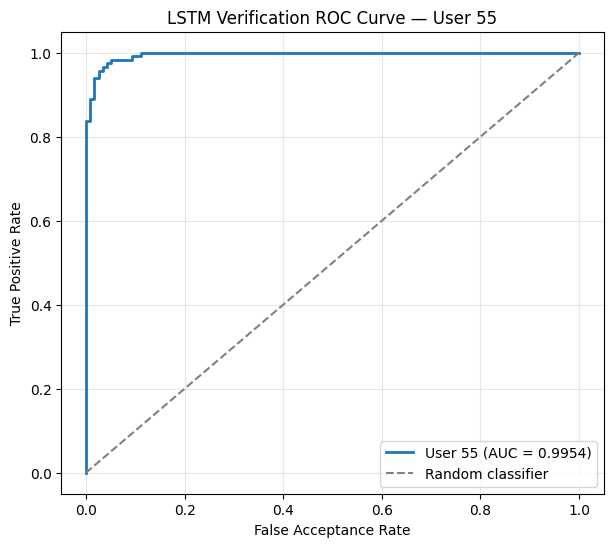

Saved final LSTM verification results to:
/content/drive/MyDrive/processed_data/results


In [5]:
# Save and plot the LSTM verification ROC
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/results"
)

PLOTS_DIR = Path(
    "/content/drive/MyDrive/processed_data/plots"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load results from the checkpoint if necessary
if "lstm_verification_results_df" not in globals():
    lstm_verification_results_df = pd.read_csv(
        RESULTS_DIR / "lstm_verification_partial_results.csv"
    )

# Use the saved ROC data for user 55
roc_user = "55"

roc_file = (
    RESULTS_DIR /
    f"lstm_verification_roc_user_{roc_user}.npz"
)

roc_data = np.load(roc_file)

plt.figure(figsize=(7, 6))

plt.plot(
    roc_data["FPR"],
    roc_data["TPR"],
    linewidth=2,
    label=f"User {roc_user} "
          f"(AUC = {float(roc_data['AUC']):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

plt.xlabel("False Acceptance Rate")
plt.ylabel("True Positive Rate")
plt.title(
    f"LSTM Verification ROC Curve — User {roc_user}"
)
plt.legend()
plt.grid(True, alpha=0.3)

roc_path = (
    PLOTS_DIR / "lstm_verification_roc_user_55.png"
)

plt.savefig(
    roc_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Save final results
lstm_verification_results_df.to_csv(
    RESULTS_DIR / "lstm_verification_results_by_user.csv",
    index=False
)

lstm_verification_results_df[
    ["FAR", "FRR", "EER", "AUC"]
].agg(["mean", "std"]).to_csv(
    RESULTS_DIR / "lstm_verification_summary.csv"
)

print("Saved final LSTM verification results to:")
print(RESULTS_DIR)